# Customer Churn Prediction

## Overview

This project builds a machine learning model to predict whether a customer is likely to churn.

The project covers:
- Data cleaning and preprocessing
- Exploratory data analysis
- Feature engineering and selection
- Multiple classification models
- Hyperparameter tuning
- Model evaluation
- Churn probability and threshold analysis
- Saving and using the trained model

## Objective

The objective of this project is to identify customers who are likely to churn so that businesses can take proactive retention measures.

Since missing a potential churner can be costly, the project also analyzes different classification thresholds rather than relying only on the default 0.5 threshold.

## Import Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    make_scorer
)

import joblib

## Load Dataset

In [69]:
from google.colab import files
uploaded=files.upload()

Saving Telco_customer_churn.xlsx to Telco_customer_churn (1).xlsx


In [70]:
df=pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Data Understanding

In [71]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 33)


### Checking for Missing Values

We check each column for missing values to determine whether any columns or rows require cleaning.

In [72]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


### Removing High-Missing-Value Columns

The `Churn Reason` column contains a large number of missing values. Since this feature is unavailable for a substantial portion of customers, it is removed from the dataset.

In [73]:
df.drop("Churn Reason", axis=1, inplace=True)

In [74]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [76]:
df.nunique()

,0
CustomerID,7043
Count,1
Country,1
State,1
City,1129
Zip Code,1652
Lat Long,1652
Latitude,1652
Longitude,1651
Gender,2


In [77]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [78]:
df['Churn Label'].value_counts(normalize=True)*100

,proportion
Churn Label,
No,73.463013
Yes,26.536987


In [79]:
df['City'].value_counts()

,count
City,
Los Angeles,305
San Diego,150
San Jose,112
Sacramento,108
San Francisco,104
...,...
Chester,4
Big Bar,4
Washington,4


In [80]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

df.drop(columns=columns_to_drop, inplace=True)

### Removing Target-Derived and Non-Predictive Features

The columns `Churn Value`, `Churn Score`, and `CLTV` are excluded from the model.

`Churn Value` directly represents the churn outcome, while `Churn Score` is a churn-related score that could introduce target leakage. `CLTV` is also excluded to keep the model focused on customer and service characteristics available for prediction.

In [81]:
model_excluded_columns = [
    "Churn Value",
    "Churn Score",
    "CLTV"
]

df.drop(columns=model_excluded_columns, inplace=True)

In [82]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

### Handling `Total Charges`

The `Total Charges` column contains 11 blank string values, causing pandas to interpret the column as an object rather than a numeric feature. These values are converted to missing values and the corresponding rows are removed.

In [84]:
df[df["Total Charges"].apply(lambda x: isinstance(x, str))]["Total Charges"]

,Total Charges
2234,
2438,
2568,
2667,
2856,
4331,
4687,
5104,
5719,
6772,


In [85]:
df.loc[df["Total Charges"].apply(lambda x: isinstance(x, str)), "Total Charges"].apply(repr)

,Total Charges
2234,' '
2438,' '
2568,' '
2667,' '
2856,' '
4331,' '
4687,' '
5104,' '
5719,' '
6772,' '


In [86]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

print("Missing Total Charges:", df["Total Charges"].isnull().sum())

df = df.dropna(subset=["Total Charges"])

Missing Total Charges: 11


### Dataset After Cleaning

After handling missing values and removing unnecessary columns, we inspect the final dataset structure and data types.

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   object 
 3   Dependents         7032 non-null   object 
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   object 
 6   Multiple Lines     7032 non-null   object 
 7   Internet Service   7032 non-null   object 
 8   Online Security    7032 non-null   object 
 9   Online Backup      7032 non-null   object 
 10  Device Protection  7032 non-null   object 
 11  Tech Support       7032 non-null   object 
 12  Streaming TV       7032 non-null   object 
 13  Streaming Movies   7032 non-null   object 
 14  Contract           7032 non-null   object 
 15  Paperless Billing  7032 non-null   object 
 16  Payment Method     7032 non-n

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the distribution of the target variable and identify relationships between customer characteristics and churn.

### Churn Distribution

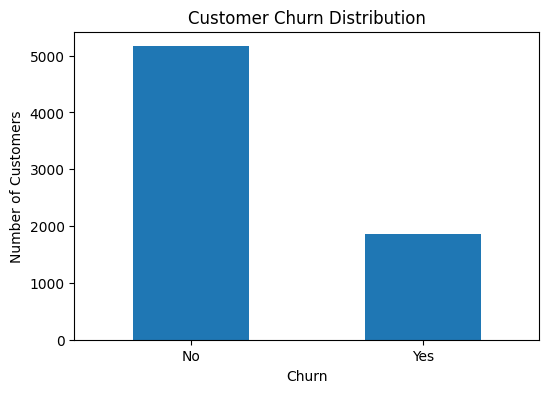

In [88]:
churn_counts = df["Churn Label"].value_counts()

plt.figure(figsize=(6, 4))
churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

The dataset contains substantially more customers who did not churn than customers who churned, indicating a class imbalance. Approximately 73% of customers did not churn, while 27% churned.

### Numerical Features vs Churn

We compare the average tenure, monthly charges, and total charges of customers who churned and those who remained.

In [89]:
numerical_churn = df.groupby("Churn Label")[
    ["Tenure Months", "Monthly Charges", "Total Charges"]
].mean()

numerical_churn

,Tenure Months,Monthly Charges,Total Charges
Churn Label,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


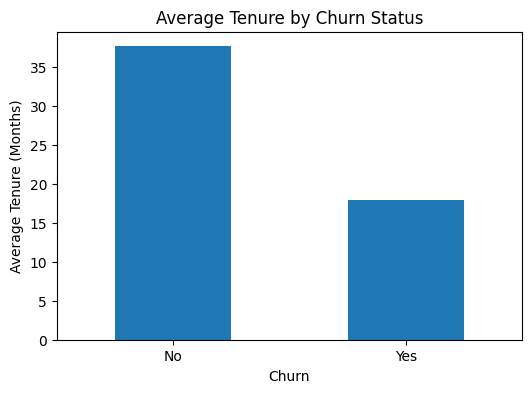

In [90]:
plt.figure(figsize=(6, 4))

df.groupby("Churn Label")["Tenure Months"].mean().plot(kind="bar")

plt.title("Average Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)

plt.show()

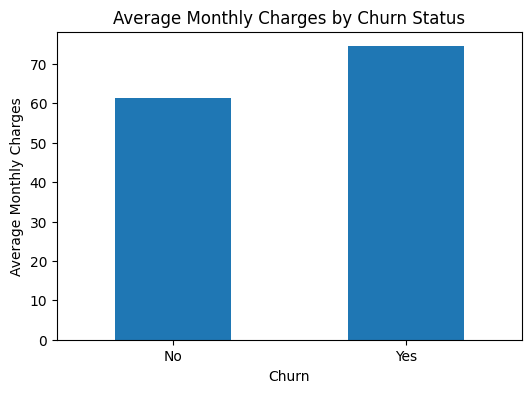

In [91]:
plt.figure(figsize=(6, 4))

df.groupby("Churn Label")["Monthly Charges"].mean().plot(kind="bar")

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)

plt.show()

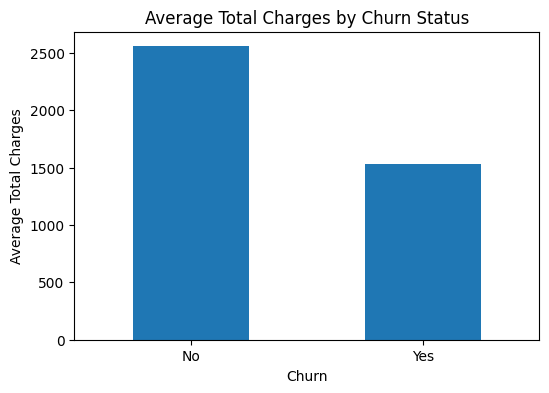

In [92]:
plt.figure(figsize=(6, 4))

df.groupby("Churn Label")["Total Charges"].mean().plot(kind="bar")

plt.title("Average Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Total Charges")
plt.xticks(rotation=0)

plt.show()

### Churn Rate by Contract Type

We examine whether customer contract type is associated with different churn rates.

In [93]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


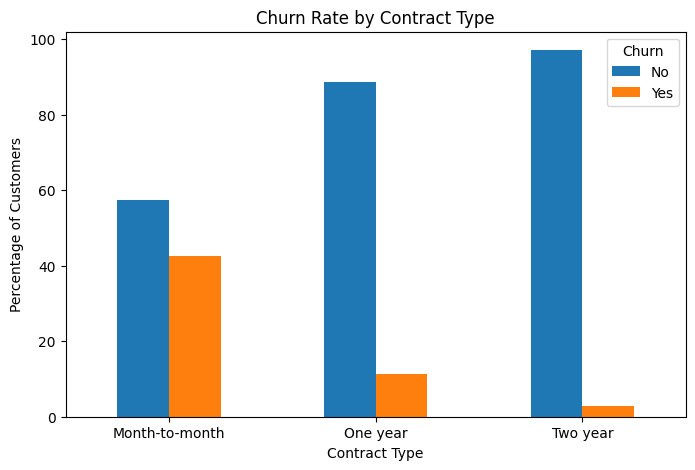

In [94]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

Customers on month-to-month contracts show substantially higher churn rates than customers on one-year or two-year contracts. This suggests that contract type is an important variable for predicting churn.

### Churn Rate by Internet Service

We examine whether the type of internet service is associated with different customer churn rates.

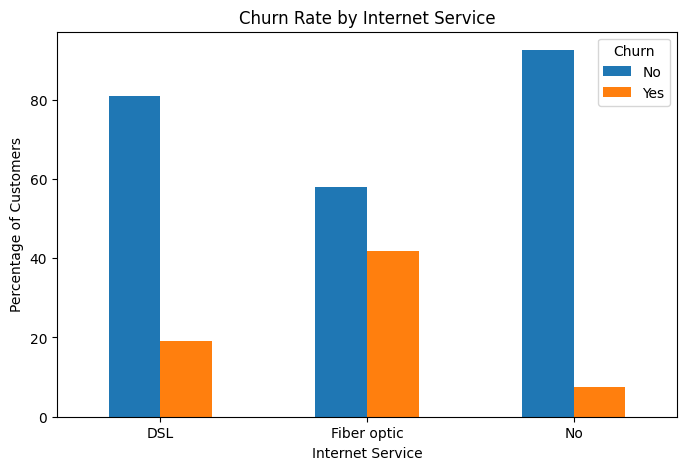

In [95]:
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

Customers using fiber optic internet have a substantially higher churn rate than customers using DSL or customers without internet service. Internet service type therefore appears to be an important predictor of churn.

## Feature Selection

The target variable is `Churn Label`. All remaining columns are initially treated as input features.

Features that could introduce target leakage or do not provide useful predictive information have already been removed during data cleaning.

In [96]:
y = df["Churn Label"]
X = df.drop(columns=["Churn Label"])

In [97]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7032, 19)
Target shape: (7032,)


## Train-Test Split

The dataset is divided into training and testing sets. The model is trained using 80% of the data and evaluated on the remaining 20%.

Stratification is used to preserve the proportion of churned and non-churned customers in both sets.

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Data Preprocessing

Machine learning models require numerical input. Numerical features are standardized using `StandardScaler`, while categorical features are converted into numerical representations using one-hot encoding.

A `ColumnTransformer` applies the appropriate preprocessing to each type of feature.

In [99]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ), categorical_features)
    ]
)

## Model Training

### Logistic Regression

Logistic Regression is used as the first baseline classification model. It provides a simple and interpretable benchmark for predicting customer churn.

In [100]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

The pipeline is fitted using only the training data. The preprocessing steps are also learned from the training set to avoid data leakage.

In [101]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model', LogisticRegression())])

### Logistic Regression Evaluation

In [102]:
y_pred = logistic_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8045486851457001

Confusion Matrix:
[[907 126]
 [149 225]]

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.88      0.87      1033
         Yes       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### Random Forest

In [103]:
rf_model = RandomForestClassifier(random_state=42)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

In [104]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.7903340440653873

Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Gradient Boosting

In [105]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", gb_model)
])

In [106]:
gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [107]:
gb_pred = gb_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, gb_pred))
print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

Accuracy: 0.798862828713575

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.89      0.87      1033
         Yes       0.64      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



## Model Comparison

The baseline models are compared using accuracy and F1-score for the churn class. Since identifying customers who are likely to churn is the main objective, churn recall and F1-score are particularly important.

In [108]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Churn F1": [
        f1_score(y_test, y_pred, pos_label="Yes"),
        f1_score(y_test, rf_pred, pos_label="Yes"),
        f1_score(y_test, gb_pred, pos_label="Yes")
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(3)
comparison["Churn F1"] = comparison["Churn F1"].round(3)

comparison

,Model,Accuracy,Churn F1
0,Logistic Regression,0.805,0.621
1,Random Forest,0.790,0.564
2,Gradient Boosting,0.799,0.590


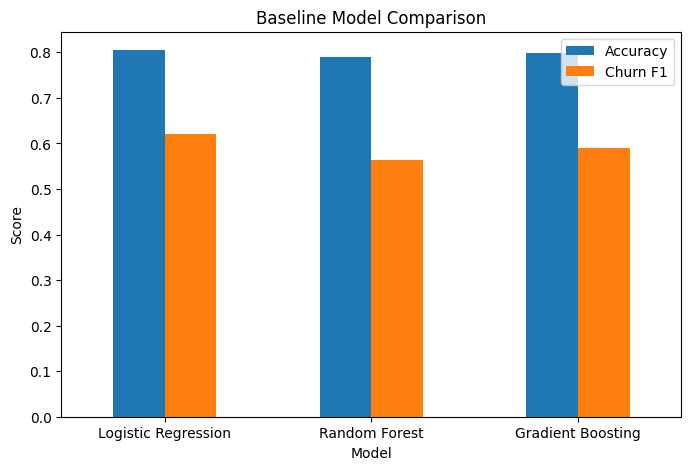

In [109]:
comparison.set_index("Model")[["Accuracy", "Churn F1"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Baseline Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

## Hyperparameter Tuning

The best-performing baseline model and Random Forest are tuned using GridSearchCV.

F1-score for the churn class (`Yes`) is used as the optimization metric because correctly identifying customers who are likely to churn is more important than accuracy alone.

### Random Forest Tuning

In [110]:
churn_f1 = make_scorer(f1_score, pos_label="Yes")

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=churn_f1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Tenure '
                                                                          'Months',
                                                                          'Monthly '
                                                                          'Charges',
                                                                          'Total '
                                                                          'Charges']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Gender',
                                                                          'Senior '
                                                                          'Citizen',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'Phone '
                                                                          'Service',
                                                                          'Multiple '
                                                                          'Lines',
                                                                          'Internet '
                                                                          'Service',
                                                                          'Online '
                                                                          'Secu...
                                                                          'TV',
                                                                          'Streaming '
                                                                          'Movies',
                                                                          'Contract',
                                                                          'Paperless '
                                                                          'Billing',
                                                                          'Payment '
                                                                          'Method'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring=make_scorer(f1_score, response_method='predict', pos_label=Yes))

In [111]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best CV F1:
0.5927990623470031


### Tuned Random Forest Evaluation

In [112]:
best_rf = grid_search.best_estimator_

tuned_rf_pred = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, tuned_rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, tuned_rf_pred))

Test Accuracy: 0.7931769722814499

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1033
         Yes       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



### Logistic Regression Tuning

In [113]:
logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

logreg_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logreg_param_grid,
    cv=5,
    scoring=churn_f1,
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

print("Best parameters:")
print(logreg_grid.best_params_)

print("\nBest CV F1:")
print(logreg_grid.best_score_)

Best parameters:
{'model__C': 10}

Best CV F1:
0.6140912605977634


### Tuned Logistic Regression Evaluation

In [114]:
best_logreg = logreg_grid.best_estimator_

tuned_logreg_pred = best_logreg.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, tuned_logreg_pred))
print("\nClassification Report:")
print(classification_report(y_test, tuned_logreg_pred))

Test Accuracy: 0.8045486851457001

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.88      0.87      1033
         Yes       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Churn Probability and Threshold Analysis

By default, a classification model predicts churn when the estimated probability is at least 0.5.

However, the optimal threshold depends on the business objective. Lowering the threshold can increase recall, allowing the company to identify more potential churners, but it also increases false positives.

In [115]:
y_prob = best_logreg.predict_proba(X_test)[:, 1]

In [116]:
for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_threshold_pred = [
        "Yes" if p >= threshold else "No"
        for p in y_prob
    ]

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_threshold_pred))


Threshold: 0.3
              precision    recall  f1-score   support

          No       0.90      0.75      0.82      1033
         Yes       0.52      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.75      0.76      1407


Threshold: 0.4
              precision    recall  f1-score   support

          No       0.88      0.82      0.85      1033
         Yes       0.58      0.70      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407


Threshold: 0.5
              precision    recall  f1-score   support

          No       0.86      0.88      0.87      1033
         Yes       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80   

### Threshold Selection

A threshold of 0.4 provides a useful balance for the customer-retention use case. At this threshold, the model identifies approximately 70% of actual churners, compared with approximately 60% at the default 0.5 threshold.

This comes at the cost of lower precision, meaning more customers who are predicted as churners will not actually churn. The final threshold should therefore be determined based on the relative cost of missed churners versus unnecessary retention efforts.

## ROC-AUC Evaluation

ROC-AUC measures how well the model separates customers who churn from customers who do not across different classification thresholds.

In [117]:
y_prob = best_logreg.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.8425423588426835


The final Logistic Regression model achieved a ROC-AUC of approximately 0.843, indicating good ability to distinguish between customers who churn and those who remain.

## Feature Interpretation

Because Logistic Regression is an interpretable model, its coefficients can be examined to understand which features are associated with higher or lower predicted churn probability.

Positive coefficients push the prediction toward churn, while negative coefficients push it toward non-churn.

In [118]:
logreg_model = best_logreg.named_steps["model"]

feature_names = best_logreg.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = logreg_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
10,cat__Internet Service_Fiber optic,1.760441
2,num__Total Charges,0.689305
21,cat__Streaming TV_Yes,0.669504
23,cat__Streaming Movies_Yes,0.625765
9,cat__Multiple Lines_Yes,0.515127
28,cat__Payment Method_Electronic check,0.383821
26,cat__Paperless Billing_Yes,0.275691
5,cat__Partner_Yes,0.239181
17,cat__Device Protection_Yes,0.192486
29,cat__Payment Method_Mailed check,0.081080


In [119]:
print("Top features associated with churn:")
display(coef_df.head(10))

print("\nTop features associated with non-churn:")
display(coef_df.tail(10).sort_values("Coefficient"))

Top features associated with churn:


,Feature,Coefficient
10,cat__Internet Service_Fiber optic,1.760441
2,num__Total Charges,0.689305
21,cat__Streaming TV_Yes,0.669504
23,cat__Streaming Movies_Yes,0.625765
9,cat__Multiple Lines_Yes,0.515127
28,cat__Payment Method_Electronic check,0.383821
26,cat__Paperless Billing_Yes,0.275691
5,cat__Partner_Yes,0.239181
17,cat__Device Protection_Yes,0.192486
29,cat__Payment Method_Mailed check,0.081080



Top features associated with non-churn:


,Feature,Coefficient
6,cat__Dependents_Yes,-1.637070
0,num__Tenure Months,-1.418625
25,cat__Contract_Two year,-1.378455
1,num__Monthly Charges,-1.299464
8,cat__Multiple Lines_No phone service,-0.870763
24,cat__Contract_One year,-0.801252
7,cat__Phone Service_Yes,-0.686217
22,cat__Streaming Movies_No internet service,-0.262615
16,cat__Device Protection_No internet service,-0.262615
11,cat__Internet Service_No,-0.262615


### Interpretation Note

The coefficients represent associations within the fitted model and should not be interpreted as proof of causation. The magnitude of coefficients should also be interpreted carefully because numerical features were standardized while categorical features were one-hot encoded.

## Final Model

Based on the baseline model comparison and hyperparameter tuning, Logistic Regression was selected as the final model.

The tuned model achieved:
- Accuracy: ~80.45%
- Churn precision: ~64%
- Churn recall: ~60%
- Churn F1-score: ~62%
- ROC-AUC: ~0.843

For the customer-retention use case, a probability threshold of 0.4 was selected to improve churn recall to approximately 70%.

## Save Final Model

The complete preprocessing and Logistic Regression pipeline is saved using Joblib so that it can be reused for predictions without retraining.

In [120]:
joblib.dump(best_logreg, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [121]:
model = joblib.load("customer_churn_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


## Example Prediction

The saved model can be used to estimate the probability that a new customer will churn.

In [122]:
new_customer = pd.DataFrame({
    "Gender": ["Male"],
    "Senior Citizen": ["No"],
    "Partner": ["No"],
    "Dependents": ["No"],
    "Tenure Months": [5],
    "Phone Service": ["Yes"],
    "Multiple Lines": ["No"],
    "Internet Service": ["Fiber optic"],
    "Online Security": ["No"],
    "Online Backup": ["Yes"],
    "Device Protection": ["No"],
    "Tech Support": ["No"],
    "Streaming TV": ["Yes"],
    "Streaming Movies": ["Yes"],
    "Contract": ["Month-to-month"],
    "Paperless Billing": ["Yes"],
    "Payment Method": ["Electronic check"],
    "Monthly Charges": [85.0],
    "Total Charges": [425.0]
})

In [123]:
probability = model.predict_proba(new_customer)[0, 1]

prediction = "Yes" if probability >= 0.4 else "No"

print("Churn Probability:", probability)
print("Prediction:", prediction)

Churn Probability: 0.8070246324239615
Prediction: Yes


In [124]:
if probability >= 0.4:
    risk = "At Risk"
else:
    risk = "Lower Risk"

print("Churn Probability:", round(probability * 100, 2), "%")
print("Customer Risk:", risk)

Churn Probability: 80.7 %
Customer Risk: At Risk


## Conclusion

This project developed an end-to-end customer churn prediction system using supervised machine learning.

After cleaning and exploring the dataset, three classification models were evaluated: Logistic Regression, Random Forest, and Gradient Boosting. Logistic Regression achieved the strongest baseline performance and remained the best-performing model after hyperparameter tuning.

The final model achieved a ROC-AUC of approximately 0.843. Threshold analysis showed that lowering the classification threshold from 0.5 to 0.4 increased churn recall from approximately 60% to 70%, making the model more suitable for proactive customer-retention strategies.

The trained preprocessing and model pipeline was saved using Joblib and can be reused to generate predictions for new customers.